In [2]:
# %matplotlib widget
import numpy as np
from sim_library.constants import k_eff, dR, m, kb, omega_eg
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path
from sim_library.simulation import simulate_pulses_single_atom, simulate_pulses_single_atom_analyt, simulate_pulses_p_dist, simulate_alg_cooling, simulate_alg_cooling_custom
from sim_library.sequences import RR3_gate, PulseSequence, UpPulse, DownPulse, FreeEvolution, gen_MDFEup_seq, gen_MDFEdown_seq, RR3_adjMDFE_500kHz
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, save_gif, plot_coolingcycles_22, fit_gaussian, fit_gaussian_custom, display_table_compare, plot_bloch_multi
from sim_library.data_io import load_p_dists

#### Time scan

In [ ]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1000

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

# MDFE = gen_MDFEdown_seq(free_time=pi/(4*dR) - (0.5*0.039286*pi/(2*dR)), rabi_freq=rabi_freq, time_steps=n_steps, detuning=dR)
MDFE = gen_MDFEdown_seq(free_time=0.11011*pi/dR, rabi_freq=rabi_freq, time_steps=n_steps, detuning=dR)

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 0
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise
    pulse_seq1 = PulseSequence()

    pulse1 = UpPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/4)
    pulse2 = UpPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/2)

    free = FreeEvolution(laser_det=(np.full(n_steps, -dR)), duration=(pi/(0.5*dR) - (1.8*0.039286*pi/(4*dR))))
    detuning = omega_eg/2
    free_time = 2*pi/(np.abs(dR-detuning))
    # free2 = FreeEvolution(laser_det=(np.full(n_steps, detuning)), duration=((9.83*free_time/16)))
    free2 = FreeEvolution(laser_det=(np.full(n_steps, detuning)), duration=(0.230357*free_time/2))
    free3 = FreeEvolution(laser_det=(np.full(n_steps, detuning)), duration=(free_time/2))
    
   

    pulse_seq1.add_pulses([pulse1, free2, MDFE, pulse1])

    wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

    if i == 0:
        wave_funcs = np.zeros((len(indices),len(times),2), dtype=np.complex128)

    wave_funcs[i,:,:] = wave_func[:,indices[i]:indices[i]+2]


angles = (np.angle(wave_funcs[:,:,1]) - np.angle(wave_funcs[:,:,0]))

angles = np.unwrap(angles, axis=1)

# fig, ax = plt.subplots()
# ax.plot(times/(rabi_time),angles.transpose()/pi)
# # ax.set_yticks([0,0.02,0.04,0.06,0.08,0.1,0.12],[r'0.00', r'0.02$\pi$', r'0.04$\pi$', r'0.06$\pi$', r'0.08$\pi$', r'0.1$\pi$', r'0.12$\pi$'])
# # ax.set_ylim(-0.005,0.12)
# ax.grid()
# ax.set_ylabel(r'Relative phase evolved (rad)')
# ax.set_xlabel(r'Time elapsed ($t_{2\pi}$)')
# ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'])
# ax.set_title('500kHz')
# # plt.ylim(0,2.1)
# # plt.xlim(0,(rabi_time/2)*1.1)

print(angles[:,-1]/pi)





# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)

[ 0.2711306  -1.84526194 -0.14631445  0.38665479]


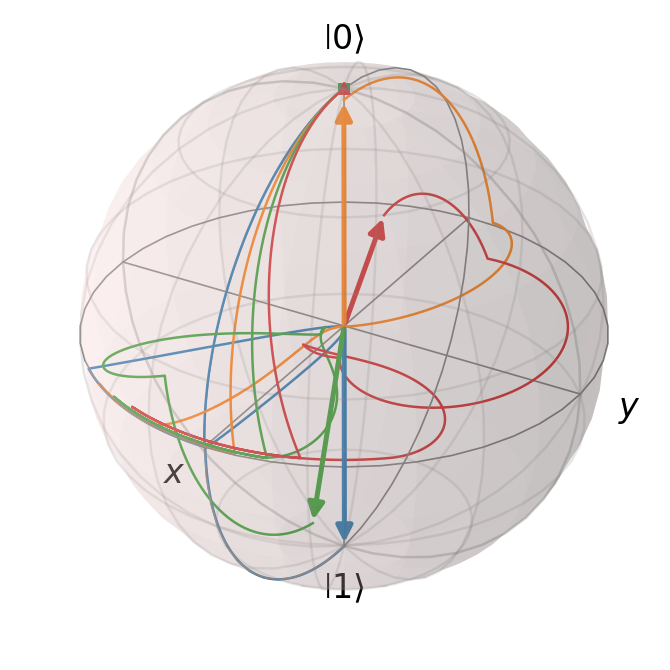

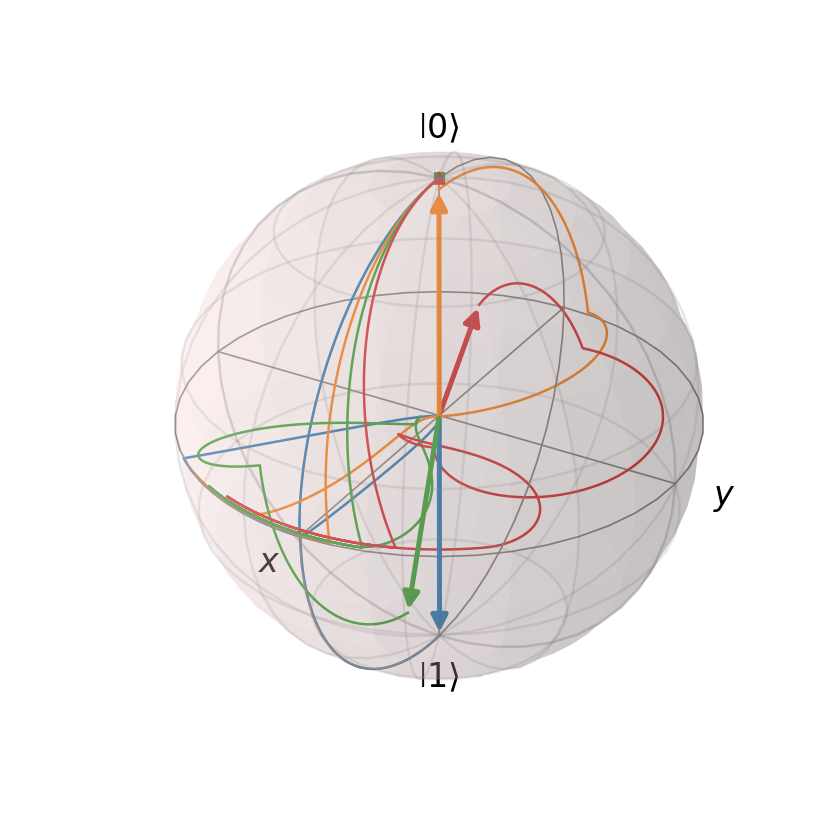

In [131]:
%matplotlib widget
b, fig = plot_bloch_multi(wave_func=wave_funcs, show=True)
fig


[ 0.13489213 -1.3296769  -0.81212849 -0.32165665]


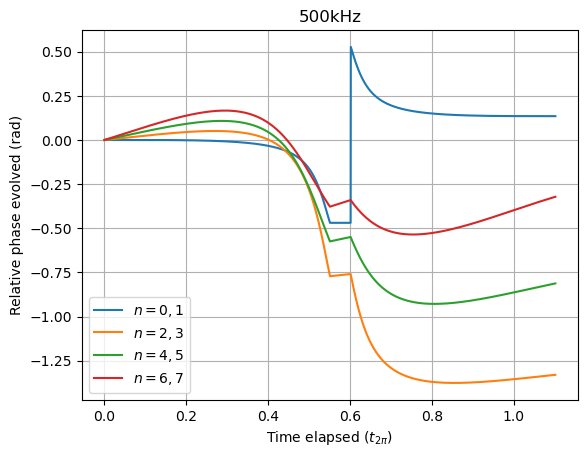

In [398]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1000

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

MDFE = gen_MDFEdown_seq(free_time=0.1*pi/(8*dR), rabi_freq=rabi_freq, time_steps=n_steps)

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 1
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise
    pulse_seq1 = PulseSequence()

    pulse1 = UpPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/4)
    pulse2 = UpPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/2)

    free = FreeEvolution(laser_det=(np.full(n_steps, -dR)), duration=(pi/(0.5*dR) - (1.8*0.039286*pi/(4*dR))))
    detuning = omega_eg/2
    free_time = 2*pi/(np.abs(dR-detuning))
    # free2 = FreeEvolution(laser_det=(np.full(n_steps, detuning)), duration=((9.83*free_time/16)))
    free2 = FreeEvolution(laser_det=(np.full(n_steps, detuning)), duration=((5*free_time/8)))
    

    pulse_seq1.add_pulses([MDFE])

    wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

    if i == 0:
        wave_funcs = np.zeros((len(indices),len(times),2), dtype=np.complex128)

    wave_funcs[i,:,:] = wave_func[:,indices[i]:indices[i]+2]


angles = (np.angle(wave_funcs[:,:,1]) - np.angle(wave_funcs[:,:,0]))

angles = np.unwrap(angles, axis=1)

fig, ax = plt.subplots()
ax.plot(times/(rabi_time),angles.transpose()/pi)
# ax.set_yticks([0,0.02,0.04,0.06,0.08,0.1,0.12],[r'0.00', r'0.02$\pi$', r'0.04$\pi$', r'0.06$\pi$', r'0.08$\pi$', r'0.1$\pi$', r'0.12$\pi$'])
# ax.set_ylim(-0.005,0.12)
ax.grid()
ax.set_ylabel(r'Relative phase evolved (rad)')
ax.set_xlabel(r'Time elapsed ($t_{2\pi}$)')
ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'])
ax.set_title('500kHz')
# plt.ylim(0,2.1)
# plt.xlim(0,(rabi_time/2)*1.1)


print(angles[:,-1]/pi)





# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)

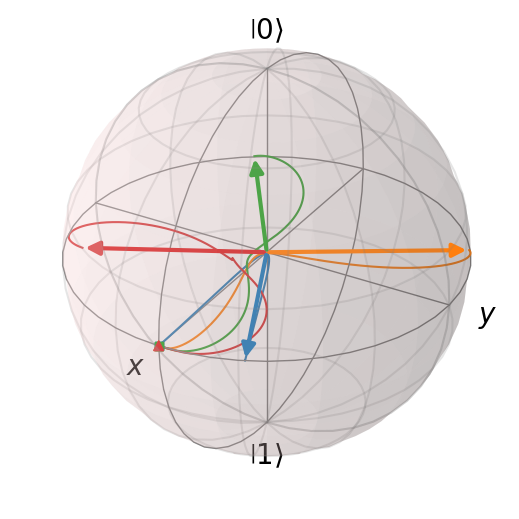

In [399]:
plot_bloch_multi(wave_func=wave_funcs, show=False)

7
11
9
13
11
15
13
17
[0.53089821 0.56192238 0.59320067 0.62486556]


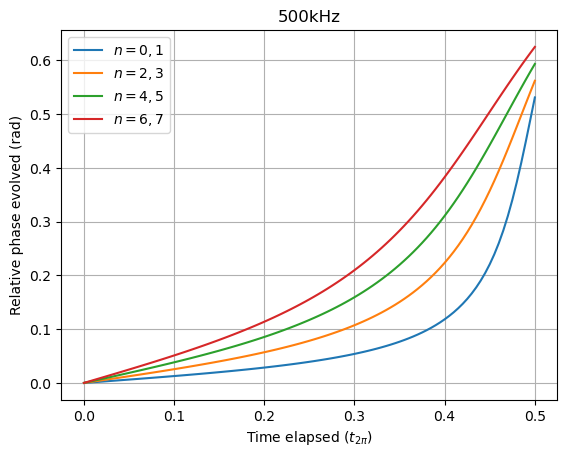

In [67]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 100

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

# MDFE = gen_MDFEdown_seq(free_time=0.039286*pi/(4*dR), rabi_freq=rabi_freq*1e5, time_steps=n_steps)

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 1
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise
    pulse_seq1 = PulseSequence()

    pulse1 = DownPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, -pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/2)

    detuning = dR/2
    free_time = 2*pi/(np.abs(dR-detuning))
    free = FreeEvolution(laser_det=(np.full(n_steps, detuning)), duration=(free_time/32))

    pulse_seq1.add_pulses([pulse1])

    wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

    if i == 0:
        wave_funcs = np.zeros((len(indices),len(times),2), dtype=np.complex128)

    wave_funcs[i,:,:] = wave_func[:,indices[i]+1:indices[i]+3]/np.linalg.norm(wave_func[-1,indices[i]+1:indices[i]+3])
    print(indices[i]-1)
    print(indices[i]+3)


angles = (np.angle(wave_funcs[:,:,1]) - np.angle(wave_funcs[:,:,0]))

angles = np.unwrap(angles, axis=1)

fig, ax = plt.subplots()
ax.plot(times/(rabi_time),angles.transpose()/pi)
# ax.set_yticks([0,0.02,0.04,0.06,0.08,0.1,0.12],[r'0.00', r'0.02$\pi$', r'0.04$\pi$', r'0.06$\pi$', r'0.08$\pi$', r'0.1$\pi$', r'0.12$\pi$'])
# ax.set_ylim(-0.005,0.12)
ax.grid()
ax.set_ylabel(r'Relative phase evolved (rad)')
ax.set_xlabel(r'Time elapsed ($t_{2\pi}$)')
ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'])
ax.set_title('500kHz')
# plt.ylim(0,2.1)
# plt.xlim(0,(rabi_time/2)*1.1)


print(angles[:,-1]/pi)





# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)

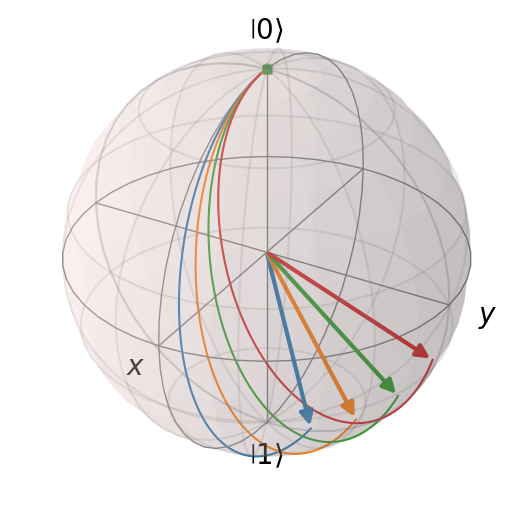

In [68]:
plot_bloch_multi(wave_func=wave_funcs, show=False)

[0.03928551 0.07840097 0.11718576]


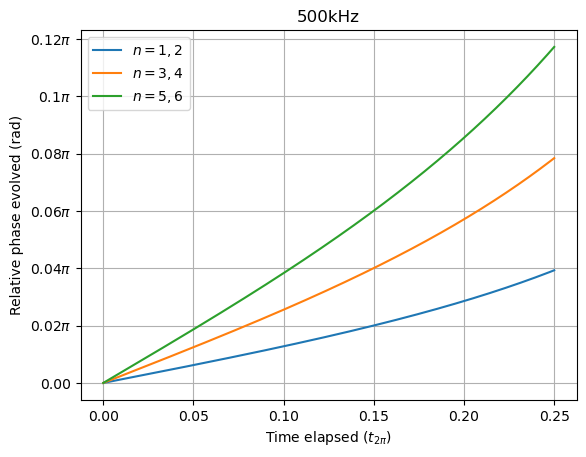

In [ ]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1000

indices = [9,11,13]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

# MDFE = gen_MDFEdown_seq(free_time=0.039286*pi/(4*dR), rabi_freq=rabi_freq*1e5, time_steps=n_steps)

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 0
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise
    pulse_seq1 = PulseSequence()

    pulse1 = DownPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, -pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/4)

    # detuning = 40*dR
    # free_time = 2*pi/(np.abs(dR-detuning))
    # free = FreeEvolution(laser_det=(np.full(n_steps, -detuning)), duration=(free_time/2))

    pulse_seq1.add_pulses([pulse1])

    wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

    if i == 0:
        wave_funcs = np.zeros((len(indices),len(times),2), dtype=np.complex128)

    wave_funcs[i,:,:] = wave_func[:,indices[i]:indices[i]+2]


angles = (np.angle(wave_funcs[:,:,1]) - np.angle(wave_funcs[:,:,0]))

angles = np.unwrap(angles, axis=1)

fig, ax = plt.subplots()
ax.plot(times/(rabi_time),angles.transpose()/pi)
ax.set_yticks([0,0.02,0.04,0.06,0.08,0.1,0.12],[r'0.00', r'0.02$\pi$', r'0.04$\pi$', r'0.06$\pi$', r'0.08$\pi$', r'0.1$\pi$', r'0.12$\pi$'])
# ax.set_ylim(-0.005,0.12)
ax.grid()
ax.set_ylabel(r'Relative phase evolved (rad)')
ax.set_xlabel(r'Time elapsed ($t_{2\pi}$)')
ax.legend([r'$n=1,2$',r'$n=3,4$',r'$n=5,6$'])
ax.set_title('500kHz')
# plt.ylim(0,2.1)
# plt.xlim(0,(rabi_time/2)*1.1)


print(angles[:,-1]/pi)





# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)

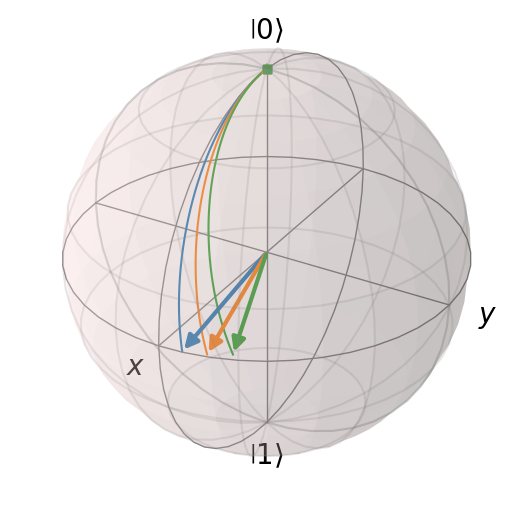

In [105]:
plot_bloch_multi(wave_func=wave_funcs, show=False)

#### Rabi scan

[-6.12323400e-17  6.07004562e-01  1.16452539e+00  1.66471005e+00]


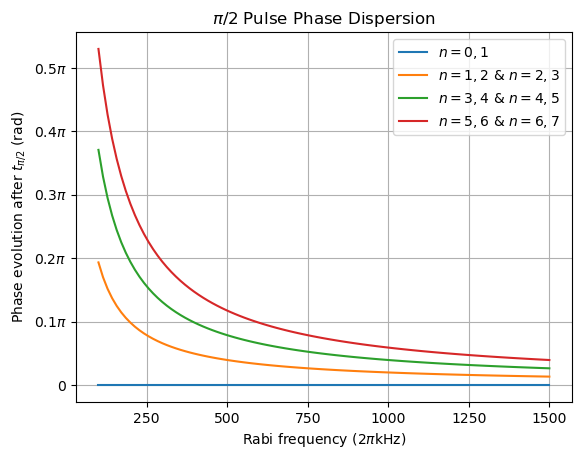

In [148]:

# Rabi frequency in 2*pi*Hz units
# rabi_freq = 2*pi*5e5
# rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

# MDFE = gen_MDFEdown_seq(free_time=0.039286*pi/(4*dR), rabi_freq=rabi_freq*1e5, time_steps=n_steps)
rabis = 2*pi*np.logspace(5,6.7,num=100,base=10)
rabis = 2*pi*np.linspace(1e5,1.5e6,100)
phases = np.zeros((len(indices),len(rabis)))

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 0
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise
    
    for r, rabi in enumerate(rabis):
        rabi_time = 2*pi/rabi
        pulse_seq1 = PulseSequence()
        if indices[i] % 2 ==0:
            pulse1 = UpPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi), duration=rabi_time/4)
        else:
            pulse1 = DownPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, -pi/2), rabi_freq=np.full(n_steps,rabi), duration=rabi_time/4)
        # detuning = 40*dR
        # free_time = 2*pi/(np.abs(dR-detuning))
        # free = FreeEvolution(laser_det=(np.full(n_steps, -detuning)), duration=(free_time/2))

        pulse_seq1.add_pulses([pulse1])

        wave_func, _ = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

        

        phases[i,r] = (np.angle(wave_func[-1,indices[i]+1]) - np.angle(wave_func[-1,indices[i]]))

    phases[i,:] = np.unwrap(phases[i,:])

phases[-1,:] = phases[-1,:] + 2*pi


fig, ax = plt.subplots()
ax.plot(rabis/(2*pi*1e3),phases.transpose()/pi)
ax.set_yticks([0,0.1,0.2,0.3,0.4,0.5],[r'0', r'0.1$\pi$', r'0.2$\pi$', r'0.3$\pi$', r'0.4$\pi$', r'0.5$\pi$'])
# ax.set_ylim(-0.005,0.12)
ax.set_xticks(np.linspace(250,1500,6))
ax.grid()
ax.set_ylabel(r'Phase evolution after $t_{\pi/2}$ (rad)')
ax.set_xlabel(r'Rabi frequency ($2\pi$kHz)')
ax.legend([r'$n=0,1$',r'$n=1,2$ & $n=2,3$',r'$n=3,4$ & $n=4,5$',r'$n=5,6$ & $n=6,7$'])
ax.set_title(r'$\pi/2$ Pulse Phase Dispersion');
# plt.ylim(0,2.1)
# plt.xlim(0,(rabi_time/2)*1.1)


# print(angles[:,-1]/pi)


print(phases[:,0])


# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)

## MDFE Fidlelity

#### pi/8 +

[1.00243524 1.00168517 1.00072507 1.0020252 ]
[0.97019732 0.96577408 0.77465367 0.7313546 ]
1.0015851585158517
0.8604508442354124


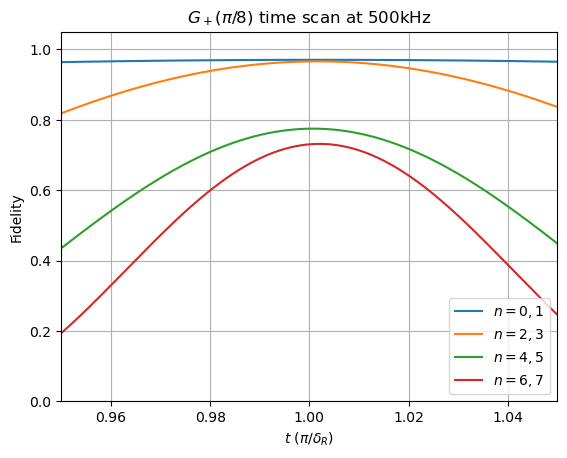

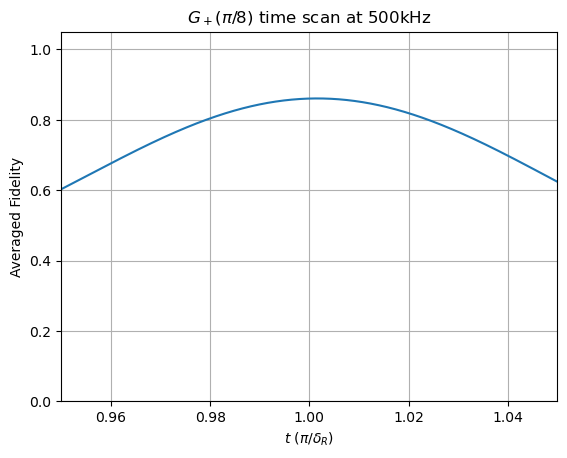

In [15]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

target_states = np.full((len(indices),2),1/np.sqrt(2), dtype=np.complex128)
target_states[:,1] = target_states[:,1]*np.exp(1j*pi*np.array([0.125,0.625,1.125,1.625]))

free_times = np.linspace(0.95*pi/dR, 1.05*pi/dR, 10000)

fidelities = np.zeros((len(indices),len(free_times)))
# fid_sum = np.zeros(len(free_times))

# Set doppler shift
atom_veloc = 0.0 # Stationary

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 1
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

    for t, time in enumerate(free_times):
        pulse_seqq = PulseSequence()
        detuning = omega_eg/2
        free_time = 2*pi/(np.abs(dR-detuning))
        free = FreeEvolution(laser_det=(np.full(n_steps, -detuning)), duration=(free_time/2))
        MDFE = gen_MDFEdown_seq(free_time=time, rabi_freq=rabi_freq, time_steps=n_steps, detuning=dR)
        pulse_seqq.add_pulses([MDFE, free])
        wave_func, _ = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seqq, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

        fidelity = np.abs(np.vdot(wave_func[-1, indices[i]:indices[i]+2],target_states[i,:]))**2
        fidelities[i, t] = fidelity
        

### Individual fidelities ###
fig, ax = plt.subplots()
ax.plot(free_times*dR/pi,fidelities.transpose())

peak_locs = free_times[np.argmax(fidelities, axis=1)]
print(peak_locs*dR/pi)
print(np.max(fidelities, axis=1))

# for i in range(len(indices)):
#     ax.plot(np.full(2,peak_locs[i]*dR/pi), [0,1])

ax.set_ylim(0,1.05)
ax.set_xlim(free_times[0]*dR/pi, free_times[-1]*dR/pi)
ax.set_xlabel(r'$t$ $(\pi/\delta_R)$')
ax.set_ylabel('Fidelity')
ax.set_title(r'$G_+(\pi/8)$ time scan at 500kHz')
ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'], loc='lower right')
ax.grid()
######

### Average fidelity ###
fid_sum = np.sum(fidelities, axis=0)/len(indices)
print(free_times[np.argmax(fid_sum)]*dR/pi)
print(np.max(fid_sum))
fig, ax = plt.subplots()
ax.plot(free_times*dR/pi,fid_sum)



ax.set_ylim(0,1.05)
ax.set_xlim(free_times[0]*dR/pi, free_times[-1]*dR/pi)
ax.set_xlabel(r'$t$ $(\pi/\delta_R)$')
ax.set_ylabel('Averaged Fidelity')
ax.set_title(r'$G_+(\pi/8)$ time scan at 500kHz')
ax.grid()
######




#### pi/4 +

[ 0.12379238  0.92643264 -0.09654965  1.97437744]
[0.99746018 0.96975944 0.99251895 0.97379531]
0.12979297929792988
0.828459572322327


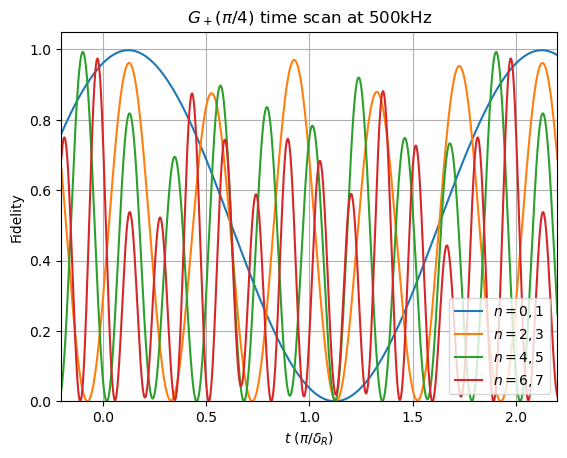

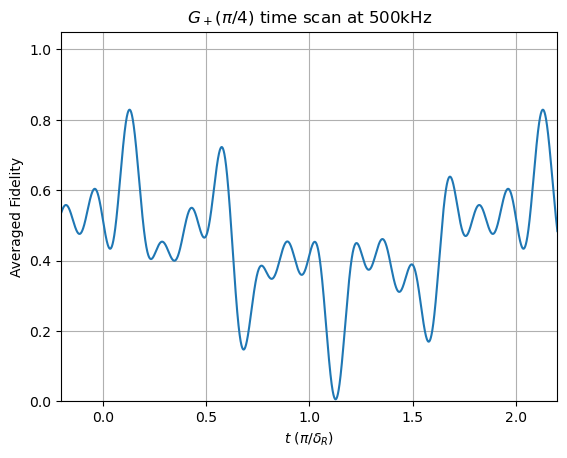

In [23]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

target_states = np.full((len(indices),2),1/np.sqrt(2), dtype=np.complex128)
target_states[:,1] = target_states[:,1]*np.exp(1j*pi*np.array([0.25,1.25,0.25,1.25]))

free_times = np.linspace(-0.2*pi/dR, 2.2*pi/dR, 10000)

fidelities = np.zeros((len(indices),len(free_times)))
# fid_sum = np.zeros(len(free_times))

# Set doppler shift
atom_veloc = 0.0 # Stationary

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 1
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

    for t, time in enumerate(free_times):
        pulse_seqq = PulseSequence()
        detuning = omega_eg/2
        free_time = 2*pi/(np.abs(dR-detuning))
        free = FreeEvolution(laser_det=(np.full(n_steps, -detuning)), duration=(free_time/2))
        MDFE = gen_MDFEdown_seq(free_time=time, rabi_freq=rabi_freq, time_steps=n_steps, detuning=dR)
        pulse_seqq.add_pulses([MDFE])
        wave_func, _ = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seqq, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

        fidelity = np.abs(np.vdot(wave_func[-1, indices[i]:indices[i]+2],target_states[i,:]))**2
        fidelities[i, t] = fidelity
        

### Individual fidelities ###
fig, ax = plt.subplots()
ax.plot(free_times*dR/pi,fidelities.transpose())

peak_locs = free_times[np.argmax(fidelities, axis=1)]
print(peak_locs*dR/pi)
print(np.max(fidelities, axis=1))

# for i in range(len(indices)):
#     ax.plot(np.full(2,peak_locs[i]*dR/pi), [0,1])

ax.set_ylim(0,1.05)
ax.set_xlim(free_times[0]*dR/pi, free_times[-1]*dR/pi)
ax.set_xlabel(r'$t$ $(\pi/\delta_R)$')
ax.set_ylabel('Fidelity')
ax.set_title(r'$G_+(\pi/4)$ time scan at 500kHz')
ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'], loc='lower right')
ax.grid()
######

### Average fidelity ###
fid_sum = np.sum(fidelities, axis=0)/len(indices)
print(free_times[np.argmax(fid_sum)]*dR/pi)
print(np.max(fid_sum))
fig, ax = plt.subplots()
ax.plot(free_times*dR/pi,fid_sum)



ax.set_ylim(0,1.05)
ax.set_xlim(free_times[0]*dR/pi, free_times[-1]*dR/pi)
ax.set_xlabel(r'$t$ $(\pi/\delta_R)$')
ax.set_ylabel('Averaged Fidelity')
ax.set_title(r'$G_+(\pi/4)$ time scan at 500kHz')
ax.grid()
######




#### pi/8 - 

[-1.5015015e-02  1.9955956e+00 -1.8018018e-03]
[0.99983886 0.99613093 0.97755428]
-0.004004004004003947
0.9897221882364509
0.9878733734278938


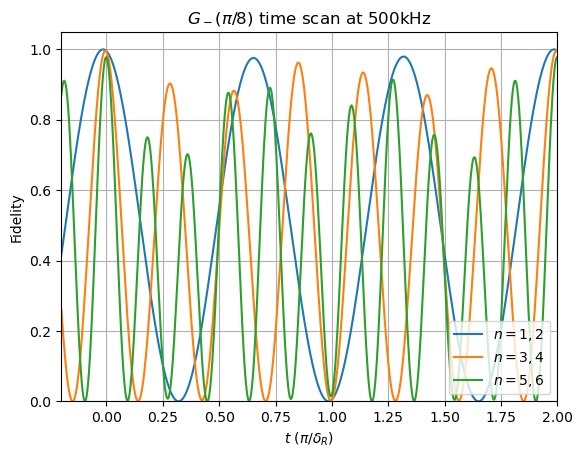

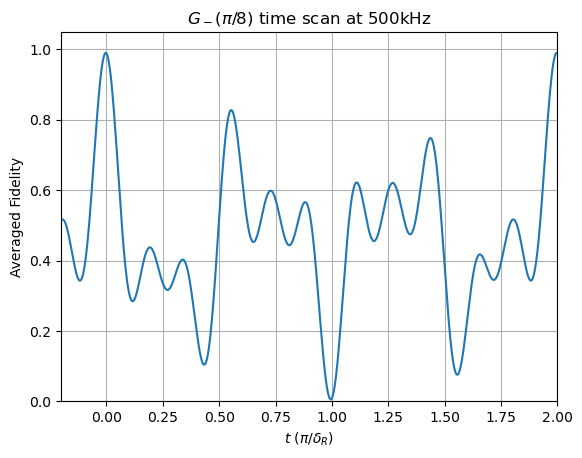

In [31]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1

indices = [9,11,13]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

target_states = np.full((len(indices),2),1/np.sqrt(2), dtype=np.complex128)
target_states[:,1] = target_states[:,1]*np.exp(1j*pi*np.array([0.325,0.825,1.325]))

free_times = np.linspace(-0.2*pi/dR, 2*pi/dR, 1000)

fidelities = np.zeros((len(indices),len(free_times)))
# fid_sum = np.zeros(len(free_times))

# Set doppler shift
atom_veloc = 0.0 # Stationary

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 1
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

    for t, time in enumerate(free_times):
        pulse_seqq = PulseSequence()
        detuning = omega_eg/2
        free_time = 2*pi/(np.abs(dR-detuning))
        free = FreeEvolution(laser_det=(np.full(n_steps, -detuning)), duration=(free_time/2))
        MDFE = gen_MDFEup_seq(free_time=time, rabi_freq=rabi_freq, time_steps=n_steps, detuning=dR)
        pulse_seqq.add_pulses([MDFE])
        wave_func, _ = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seqq, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

        fidelity = np.abs(np.vdot(wave_func[-1, indices[i]:indices[i]+2],target_states[i,:]))**2
        fidelities[i, t] = fidelity
        

### Individual fidelities ###
fig, ax = plt.subplots()
ax.plot(free_times*dR/pi,fidelities.transpose())

peak_locs = free_times[np.argmax(fidelities, axis=1)]
print(peak_locs*dR/pi)
print(np.max(fidelities, axis=1))

# for i in range(len(indices)):
#     ax.plot(np.full(2,peak_locs[i]*dR/pi), [0,1])

ax.set_ylim(0,1.05)
ax.set_xlim(free_times[0]*dR/pi, free_times[-1]*dR/pi)
ax.set_xlabel(r'$t$ $(\pi/\delta_R)$')
ax.set_ylabel('Fidelity')
ax.set_title(r'$G_-(\pi/8)$ time scan at 500kHz')
ax.legend([r'$n=1,2$',r'$n=3,4$',r'$n=5,6$'], loc='lower right')
ax.grid()
######

### Average fidelity ###
fid_sum = np.sum(fidelities, axis=0)/len(indices)
print(free_times[np.argmax(fid_sum)]*dR/pi)
print(np.max(fid_sum))
fig, ax = plt.subplots()
ax.plot(free_times*dR/pi,fid_sum)

zero_ind = np.argmin(np.abs(free_times))
print(fid_sum[zero_ind])

ax.set_ylim(0,1.05)
ax.set_xlim(free_times[0]*dR/pi, free_times[-1]*dR/pi)
ax.set_xlabel(r'$t$ $(\pi/\delta_R)$')
ax.set_ylabel('Averaged Fidelity')
ax.set_title(r'$G_-(\pi/8)$ time scan at 500kHz')
ax.grid()
######




#### pi/4 -

[0.12679768 0.12793779 0.12959796]
[0.99744486 0.96148913 0.81893888]
0.1289278927892789
0.9258506554548571
0.43880235778341237


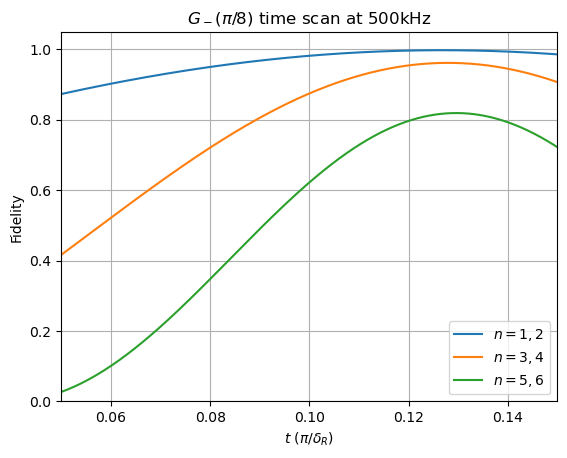

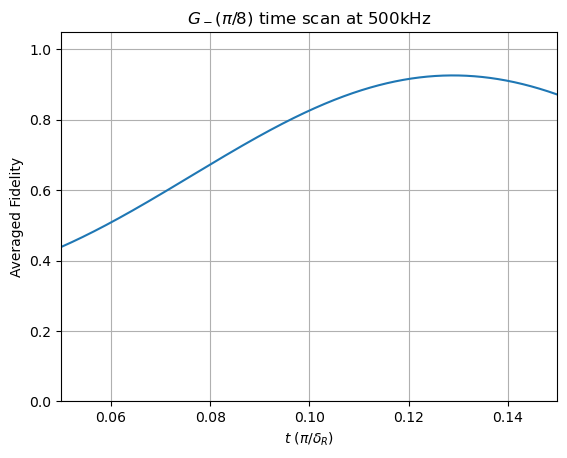

In [39]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1

indices = [9,11,13]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

target_states = np.full((len(indices),2),1/np.sqrt(2), dtype=np.complex128)
target_states[:,1] = target_states[:,1]*np.exp(1j*pi*np.array([0.75,1.75,0.75]))

free_times = np.linspace(0.05*pi/dR, 0.15*pi/dR, 10000)

fidelities = np.zeros((len(indices),len(free_times)))
# fid_sum = np.zeros(len(free_times))

# Set doppler shift
atom_veloc = 0.0 # Stationary

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 1
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

    for t, time in enumerate(free_times):
        pulse_seqq = PulseSequence()
        detuning = omega_eg/2
        free_time = 2*pi/(np.abs(dR-detuning))
        free = FreeEvolution(laser_det=(np.full(n_steps, -detuning)), duration=(free_time/2))
        MDFE = gen_MDFEup_seq(free_time=time, rabi_freq=rabi_freq, time_steps=n_steps, detuning=dR)
        pulse_seqq.add_pulses([MDFE])
        wave_func, _ = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seqq, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

        fidelity = np.abs(np.vdot(wave_func[-1, indices[i]:indices[i]+2],target_states[i,:]))**2
        fidelities[i, t] = fidelity
        

### Individual fidelities ###
fig, ax = plt.subplots()
ax.plot(free_times*dR/pi,fidelities.transpose())

peak_locs = free_times[np.argmax(fidelities, axis=1)]
print(peak_locs*dR/pi)
print(np.max(fidelities, axis=1))

# for i in range(len(indices)):
#     ax.plot(np.full(2,peak_locs[i]*dR/pi), [0,1])

ax.set_ylim(0,1.05)
ax.set_xlim(free_times[0]*dR/pi, free_times[-1]*dR/pi)
ax.set_xlabel(r'$t$ $(\pi/\delta_R)$')
ax.set_ylabel('Fidelity')
ax.set_title(r'$G_-(\pi/8)$ time scan at 500kHz')
ax.legend([r'$n=1,2$',r'$n=3,4$',r'$n=5,6$'], loc='lower right')
ax.grid()
######

### Average fidelity ###
fid_sum = np.sum(fidelities, axis=0)/len(indices)
print(free_times[np.argmax(fid_sum)]*dR/pi)
print(np.max(fid_sum))
fig, ax = plt.subplots()
ax.plot(free_times*dR/pi,fid_sum)

zero_ind = np.argmin(np.abs(free_times))
print(fid_sum[zero_ind])

ax.set_ylim(0,1.05)
ax.set_xlim(free_times[0]*dR/pi, free_times[-1]*dR/pi)
ax.set_xlabel(r'$t$ $(\pi/\delta_R)$')
ax.set_ylabel('Averaged Fidelity')
ax.set_title(r'$G_-(\pi/8)$ time scan at 500kHz')
ax.grid()
######




#### rabi scan

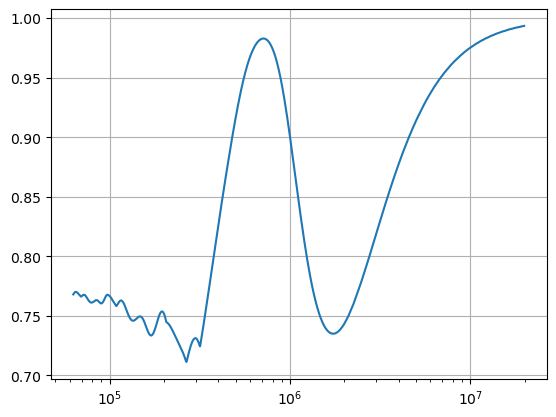

In [50]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

target_states = np.full((len(indices),2),1/np.sqrt(2), dtype=np.complex128)
target_states[:,1] = target_states[:,1]*np.exp(1j*pi*np.array([0.25,1.25,0.25,1.25]))

# Set doppler shift
atom_veloc = 0.0 # Stationary

rabis = 2*pi*np.logspace(4,6.5,1000, base=10 )

avg_fids = np.zeros(len(rabis))
locs = np.zeros(len(rabis))

free_times = np.linspace(0*pi/dR, 2*pi/dR, 1000)
fidelities = np.zeros((len(indices),len(free_times)))



for r, rabi in enumerate(rabis):
    for i in range(len(indices)):
        initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
        initial_state[indices[i]] = 1
        initial_state[indices[i]+1] = 1
        initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

        for t, time in enumerate(free_times):
            # pulse_seqq = PulseSequence()
            # detuning = omega_eg/2
            # free_time = 2*pi/(np.abs(dR-detuning))
            # free = FreeEvolution(laser_det=(np.full(n_steps, -detuning)), duration=(free_time/2))
            MDFE = gen_MDFEdown_seq(free_time=time, rabi_freq=rabi, time_steps=n_steps, detuning=dR)
            # pulse_seqq.add_pulses([MDFE, free])
            wave_func, _ = simulate_pulses_single_atom_analyt(pulse_seq=MDFE, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

            fidelity = np.abs(np.vdot(wave_func[-1, indices[i]:indices[i]+2],target_states[i,:]))**2
            fidelities[i, t] = fidelity
    fid_sum = np.sum(fidelities, axis=0)/len(indices)
    avg_fids[r] = np.max(fid_sum)
    locs[r] = free_times[np.argmax(fid_sum)]
        




fig, ax = plt.subplots()
ax.semilogx(rabis,avg_fids)



# ax.set_ylim(0,1.05)
# ax.set_xlim(free_times[0]*dR/pi, free_times[-1]*dR/pi)
# ax.set_xlabel(r'$t$ $(\pi/\delta_R)$')
# ax.set_ylabel('Averaged Fidelity')
# ax.set_title(r'$G_+(\pi/8)$ time scan at 500kHz')
ax.grid()
######




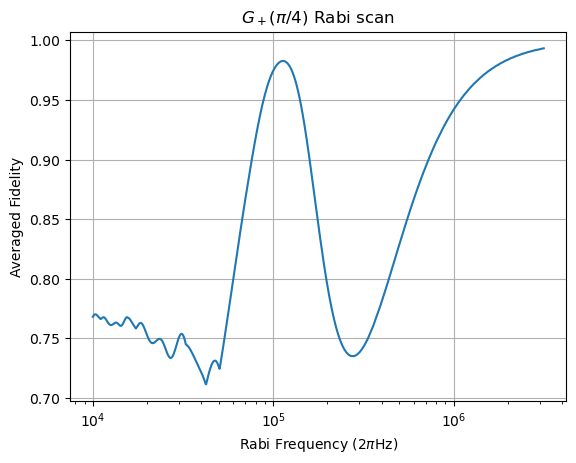

In [51]:
fig, ax = plt.subplots()
ax.semilogx(rabis/(2*pi),avg_fids)
# ax.set_ylim(0.6,1.05)
ax.set_xlabel(r'Rabi Frequency ($2\pi$Hz)')
ax.set_ylabel('Averaged Fidelity')
ax.set_title(r'$G_+(\pi/4)$ Rabi scan')
ax.grid()

In [52]:
np.savez('quartpi_rabiscan.npz',avg_fids=avg_fids, locs=locs, rabis=rabis)

### 2d fidelity scans

#### pi/4 +

In [ ]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

target_states = np.full((len(indices),2),1/np.sqrt(2), dtype=np.complex128)
target_states[:,1] = target_states[:,1]*np.exp(1j*pi*np.array([0.25,1.25,0.25,1.25]))

MDFE_times = np.linspace(0*pi/dR, 2*pi/dR, 1000)
detuning = omega_eg/2
free_time = 2*pi/(np.abs(dR-detuning))
free_times = np.linspace(0,free_time, 1000)

fidelities = np.zeros((len(indices),len(free_times),len(MDFE_times)))
# fid_sum = np.zeros(len(free_times))

# Set doppler shift
atom_veloc = 0.0 # Stationary

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 1
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

    for t1, time1 in enumerate(free_times):
        for t2, time2 in enumerate(MDFE_times):
            pulse_seqq = PulseSequence()
            
            free = FreeEvolution(laser_det=(np.full(n_steps, -detuning)), duration=(time1))
            MDFE = gen_MDFEdown_seq(free_time=time2, rabi_freq=rabi_freq, time_steps=n_steps, detuning=dR)
            pulse_seqq.add_pulses([free, MDFE])
            wave_func, _ = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seqq, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

            fidelity = np.abs(np.vdot(wave_func[-1, indices[i]:indices[i]+2],target_states[i,:]))**2
            fidelities[i, t1, t2] = fidelity
        


### Average fidelity ###
fid_sum = np.sum(fidelities, axis=0)/len(indices)
# print(free_times[np.argmax(fid_sum)]*dR/pi)
# print(np.max(fid_sum))
# fig, ax = plt.subplots()
# ax.plot(free_times*dR/pi,fid_sum)



# ax.set_ylim(0,1.05)
# ax.set_xlim(free_times[0]*dR/pi, free_times[-1]*dR/pi)
# ax.set_xlabel(r'$t$ $(\pi/\delta_R)$')
# ax.set_ylabel('Averaged Fidelity')
# ax.set_title(r'$G_+(\pi/4)$ time scan at 500kHz')
# ax.grid()
# ######




Text(0, 0.5, 'F duration')

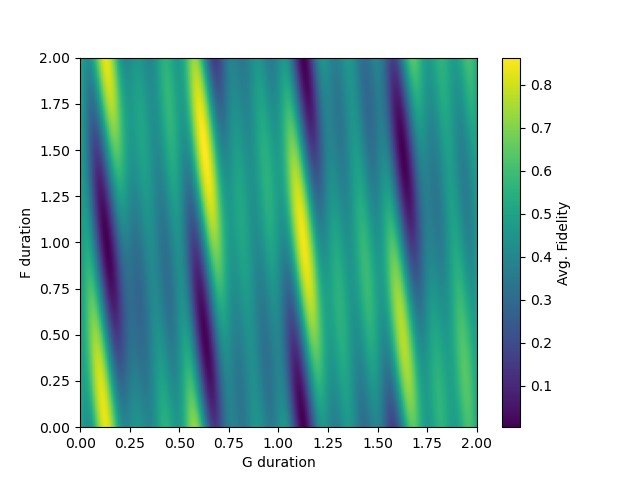

In [136]:
fig, ax = plt.subplots()
pc = ax.pcolormesh(MDFE_times*dR/pi, free_times*2/free_time, fid_sum, shading='auto', cmap='viridis')
fig.colorbar(pc, ax=ax, label='Avg. Fidelity')
ax.set_xlabel('G duration'); ax.set_ylabel('F duration')

In [149]:
print(np.unravel_index(np.argmax(fid_sum), shape=np.shape(fid_sum)))
print(fidelities[:, 754,313])

print(free_times[754]*2/free_time)
print(MDFE_times[313]*dR/pi)

(754, 313)
[0.97651718 0.89734011 0.91783128 0.65868147]
1.5095095095095097
0.6266266266266267


In [144]:
print(np.max(fidelities[3,:,:]))

0.9999957712656115


In [ ]:
# np.savez('2dtimescan_quartpi.npz', fidelities=fidelities, fid_sum = fid_sum, MDFE_times=MDFE_times, free_times=free_times)